<a href="https://colab.research.google.com/github/EkaterinaLavlinskaya/churn-prediction-svm/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ПРИМЕНЕНИЕ SVM ДЛЯ ПРОГНОЗИРОВАНИЯ ОТТОКА КЛИЕНТОВ

In [1]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

np.float64(0.8333333333333333)

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

In [4]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 39.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 19.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 23.2MB/s]


In [5]:
data = pd.read_csv('./train.csv')

In [7]:
# Для удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [9]:
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()


ЧИСЛОВЫЕ ПРИЗНАКИ:


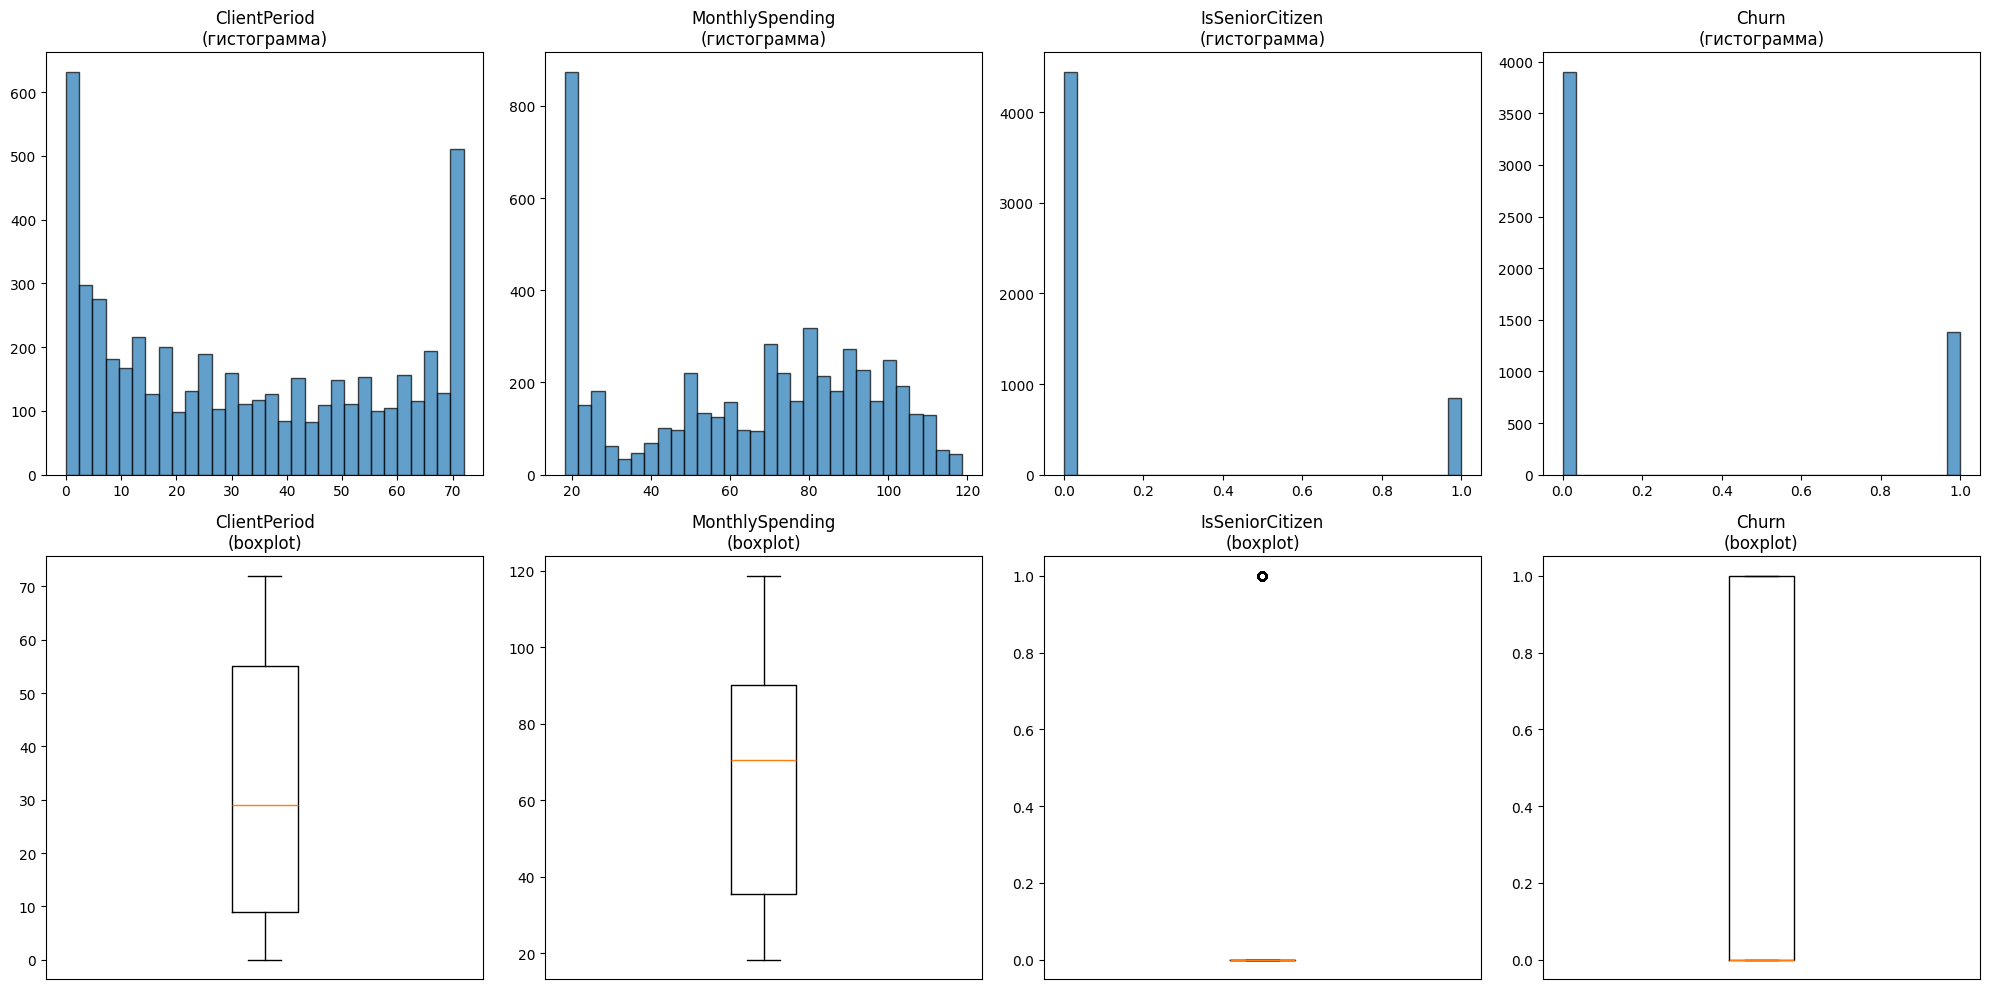

In [10]:
if numeric_features:
        print("\nЧИСЛОВЫЕ ПРИЗНАКИ:")
        fig, axes = plt.subplots(2, len(numeric_features), figsize=(5*len(numeric_features), 10))


        for i, feature in enumerate(numeric_features):
             # Гистограмма
            axes[0, i].hist(data[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
            axes[0, i].set_title(f'{feature}\n(гистограмма)')

            # Boxplot
            axes[1, i].boxplot(data[feature].dropna())
            axes[1, i].set_title(f'{feature}\n(boxplot)')
            axes[1, i].set_xticks([])

        plt.tight_layout()
        plt.show()


КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:

TotalSpent:
TotalSpent
           9
20.2       9
19.75      8
19.65      6
20.05      6
          ..
4264       1
24.25      1
1090.6     1
212.3      1
1474.75    1
Name: count, Length: 4978, dtype: int64

Sex:
Sex
Male      2655
Female    2627
Name: count, dtype: int64

HasPartner:
HasPartner
No     2705
Yes    2577
Name: count, dtype: int64

HasChild:
HasChild
No     3676
Yes    1606
Name: count, dtype: int64

HasPhoneService:
HasPhoneService
Yes    4761
No      521
Name: count, dtype: int64

HasMultiplePhoneNumbers:
HasMultiplePhoneNumbers
No                  2511
Yes                 2250
No phone service     521
Name: count, dtype: int64

HasInternetService:
HasInternetService
Fiber optic    2341
DSL            1800
No             1141
Name: count, dtype: int64

HasOnlineSecurityService:
HasOnlineSecurityService
No                     2612
Yes                    1529
No internet service    1141
Name: count, dtype: int64

HasOnlineBackup:
HasOnlineBackup


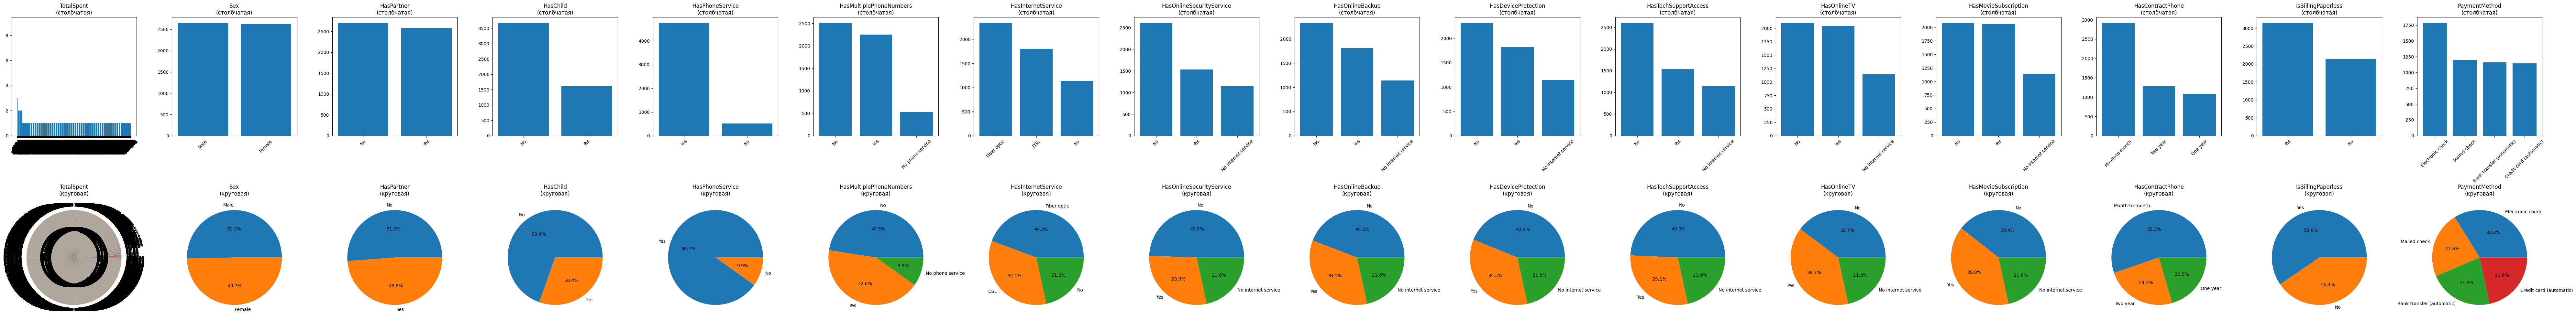

In [11]:
if categorical_features:
        print("\nКАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:")
        fig, axes = plt.subplots(2, len(categorical_features), figsize=(5*len(categorical_features), 10))

        if len(categorical_features) == 1:
            axes = axes.reshape(2, 1)

        for i, feature in enumerate(categorical_features):
            value_counts = data[feature].value_counts()

            print(f"\n{feature}:")
            print(value_counts)

            # Bar chart
            axes[0, i].bar(range(len(value_counts)), value_counts.values,
                          tick_label=value_counts.index)
            axes[0, i].set_title(f'{feature}\n(столбчатая)')
            axes[0, i].tick_params(axis='x', rotation=45)

            # Pie chart
            axes[1, i].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
            axes[1, i].set_title(f'{feature}\n(круговая)')

        plt.tight_layout()
        plt.show()

In [12]:
#пример данных для демонстрации
np.random.seed(42)

   # Числовые признаки
n_samples = 1000
df_demo = pd.DataFrame({
    'возраст': np.random.normal(35, 10, n_samples).astype(int),
    'зарплата': np.random.exponential(50000, n_samples).astype(int),
    'рейтинг': np.random.uniform(1, 5, n_samples).round(1),

    # Категориальные признаки
    'пол': np.random.choice(['Мужской', 'Женский'], n_samples),
    'образование': np.random.choice(['Среднее', 'Бакалавр', 'Магистр', 'PhD'], n_samples),
    'город': np.random.choice(['Москва', 'СПб', 'Казань', 'Новосибирск'], n_samples)
})

print("Демонстрационные данные:")
print(df_demo.head())
print("\nИнформация о данных:")
print(df_demo.info())



Демонстрационные данные:
   возраст  зарплата  рейтинг      пол образование        город
0       39      9165      1.9  Мужской         PhD  Новосибирск
1       33      5522      1.1  Мужской         PhD       Казань
2       41     50589      1.4  Мужской         PhD       Казань
3       50     61289      2.4  Женский     Магистр       Казань
4       32      1604      4.2  Женский    Бакалавр       Казань

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   возраст      1000 non-null   int64  
 1   зарплата     1000 non-null   int64  
 2   рейтинг      1000 non-null   float64
 3   пол          1000 non-null   object 
 4   образование  1000 non-null   object 
 5   город        1000 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 47.0+ KB
None


In [13]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [14]:
#смотрим какие есть столбцы в датасете
data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [15]:
# Разделяем признаки и целевую переменную
X = data.drop('Churn', axis=1)
y = data['Churn']

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [16]:
# Определяем числовые и категориальные признаки
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [17]:
# проанализируем уникальные значения в категориальных признаках

for col in categorical_features:
    print(f"{col}: {X[col].unique()}")

TotalSpent: ['1026.35' '1872.2' '75.9' ... '55.05' '2215.25' '1375.6']
Sex: ['Male' 'Female']
HasPartner: ['Yes' 'No']
HasChild: ['Yes' 'No']
HasPhoneService: ['Yes' 'No']
HasMultiplePhoneNumbers: ['No' 'Yes' 'No phone service']
HasInternetService: ['No' 'Fiber optic' 'DSL']
HasOnlineSecurityService: ['No internet service' 'No' 'Yes']
HasOnlineBackup: ['No internet service' 'No' 'Yes']
HasDeviceProtection: ['No internet service' 'No' 'Yes']
HasTechSupportAccess: ['No internet service' 'Yes' 'No']
HasOnlineTV: ['No internet service' 'No' 'Yes']
HasMovieSubscription: ['No internet service' 'No' 'Yes']
HasContractPhone: ['One year' 'Two year' 'Month-to-month']
IsBillingPaperless: ['No' 'Yes']
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']


In [18]:
# Проверяем наличие пропусков в числовых признаках
print(X_train[numeric_features].isnull().sum())

ClientPeriod       0
MonthlySpending    0
IsSeniorCitizen    0
dtype: int64


In [19]:
# Нормируем числовые признаки
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_numeric_scaled = scaler.transform(X_test[numeric_features])

In [20]:
# Преобразуем обратно в DataFrame для удобства
X_train_numeric = pd.DataFrame(
    X_train_numeric_scaled,
    columns=numeric_features,
    index=X_train.index
)
X_test_numeric = pd.DataFrame(
    X_test_numeric_scaled,
    columns=numeric_features,
    index=X_test.index
)

In [21]:
# One-Hot Encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_cat_encoded = encoder.transform(X_test[categorical_features])

In [22]:
# Получаем названия новых признаков
cat_feature_names = []
for i, feature in enumerate(categorical_features):
    categories = encoder.categories_[i]
    for category in categories:
        # Очищаем названия для лучшей читаемости
        clean_category = str(category).replace(' ', '_').replace('-', '_')
        cat_feature_names.append(f"{feature}_{clean_category}")


In [23]:
# Преобразуем в DataFrame
X_train_categorical = pd.DataFrame(
    X_train_cat_encoded,
    columns=cat_feature_names,
    index=X_train.index
)
X_test_categorical = pd.DataFrame(
    X_test_cat_encoded,
    columns=cat_feature_names,
    index=X_test.index
)

In [24]:
#ОБЪЕДИНЕНИЕ ПРИЗНАКОВ
X_train_processed = pd.concat([X_train_numeric, X_train_categorical], axis=1)
X_test_processed = pd.concat([X_test_numeric, X_test_categorical], axis=1)

In [25]:
# Линейная SVM
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_processed, y_train)

y_pred_proba = svm_linear.predict_proba(X_test_processed)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"SVM (linear) AUC: {auc:.4f}")

SVM (linear) AUC: 0.8475


In [27]:
# RBF-ядро — ищет нелинейные зависимости
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42, C=1.0, gamma='scale')
svm_rbf.fit(X_train_processed, y_train)

y_pred_proba_rbf = svm_rbf.predict_proba(X_test_processed)[:, 1]
auc_rbf = roc_auc_score(y_test, y_pred_proba_rbf)
print(f"SVM (RBF) AUC: {auc_rbf:.4f}")

SVM (RBF) AUC: 0.8184


In [29]:
#Сравнение моделей

models = {
    'LogReg': 0.84925,  # твой лучший
    'XGBoost': 0.8474,
    'RandomForest': 0.8387,
    'SVM_linear': auc,
    'SVM_rbf': auc_rbf
}

for name, score in models.items():
    print(f"{name}: {score:.4f}")

LogReg: 0.8492
XGBoost: 0.8474
RandomForest: 0.8387
SVM_linear: 0.8475
SVM_rbf: 0.8184


In [30]:
# Оценка модели
y_train_pred = svm_linear.predict(X_train_processed)
y_test_pred = svm_linear.predict(X_test_processed)
y_test_proba = svm_linear.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_test_pred, target_names=['Остался', 'Ушел']))
print(confusion_matrix(y_test, y_test_pred))
roc_auc = roc_auc_score(y_test, y_test_proba)

              precision    recall  f1-score   support

     Остался       0.85      0.89      0.87       780
        Ушел       0.65      0.55      0.59       277

    accuracy                           0.80      1057
   macro avg       0.75      0.72      0.73      1057
weighted avg       0.79      0.80      0.80      1057

[[698  82]
 [126 151]]
